In [1]:
# Installation des dépendances
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    classification_report, confusion_matrix
)

from imblearn.over_sampling import SMOTE


In [2]:
# Chargement des données

# Échantillonnage pour réduire la taille
df_full = pd.read_csv("NoNAin_adress_ALL_ADEMEwRightCols_w_TEMPERATURE.csv", low_memory=False)
df = df_full.sample(n=300000, random_state=42)
# On garde uniquement les lignes avec une étiquette DPE connue
df = df[df['etiquette_dpe'].notna()]

# Liste des variables explicatives
ls_variables_explicatives = [
    'surface_habitable_logement',
    'hauteur_sous_plafond',
    'nombre_niveau_logement',
    'type_batiment',
    'qualite_isolation_murs',
    'qualite_isolation_plancher_bas',
    'isolation_toiture',
    'periode_construction',
    'annee_construction',
    'distance',
    'type_installation_chauffage',
    'type_energie_principale_chauffage'
]

# Vérification existence
ls_variables_explicatives = [col for col in ls_variables_explicatives if col in df.columns]

# Nettoyage / imputation
for col in ls_variables_explicatives:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Variable cible
y = df['etiquette_dpe']

# Encodage des variables catégorielles
X = pd.get_dummies(df[ls_variables_explicatives], drop_first=True)

print("Données prêtes :", X.shape)
print(df['etiquette_dpe'].value_counts(normalize=True).round(3))


Données prêtes : (300000, 34)
etiquette_dpe
C    0.317
D    0.288
E    0.191
F    0.077
G    0.056
B    0.044
A    0.027
Name: proportion, dtype: float64


In [3]:
# Split train / test AVANT SMOTE (pour éviter le data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Avant SMOTE :")
print(y_train.value_counts())

# Application du SMOTE pour équilibrer les classes
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAprès SMOTE :")
print(y_train_res.value_counts())
print("\nX_train :", X_train_res.shape, "X_test :", X_test.shape)


Avant SMOTE :
etiquette_dpe
C    66564
D    60505
E    40106
F    16239
G    11738
B     9207
A     5641
Name: count, dtype: int64

Après SMOTE :
etiquette_dpe
D    66564
E    66564
C    66564
B    66564
F    66564
G    66564
A    66564
Name: count, dtype: int64

X_train : (465948, 34) X_test : (90000, 34)


In [4]:
# Définition du modèle
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

# Entraînement
rf_model.fit(X_train_res, y_train_res)

# Prédiction sur le test set
y_pred = rf_model.predict(X_test)

print(" Modèle entraîné et prédictions effectuées.")


 Modèle entraîné et prédictions effectuées.



🎯 Rapport de classification :
              precision    recall  f1-score   support

           A       0.67      0.80      0.73      2417
           B       0.38      0.60      0.46      3946
           C       0.79      0.64      0.70     28528
           D       0.54      0.54      0.54     25931
           E       0.44      0.43      0.44     17189
           F       0.28      0.24      0.26      6959
           G       0.36      0.63      0.46      5030

    accuracy                           0.54     90000
   macro avg       0.49      0.55      0.51     90000
weighted avg       0.56      0.54      0.55     90000

Accuracy : 0.542


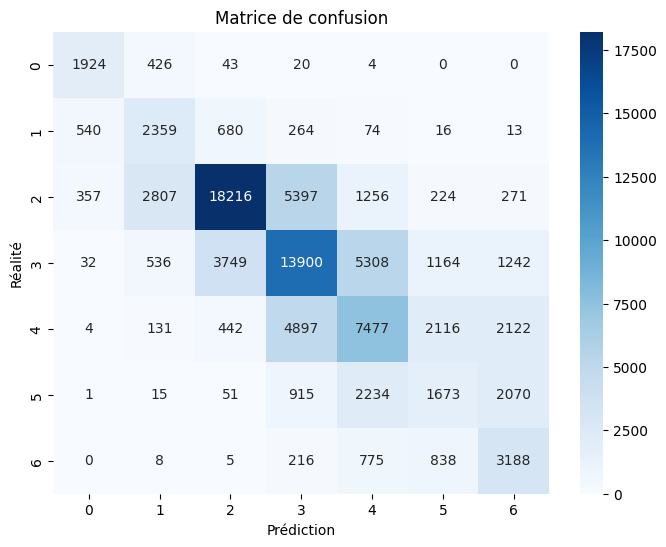

In [5]:
print("\n🎯 Rapport de classification :")
print(classification_report(y_test, y_pred))

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))

# Matrice de confusion
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.show()


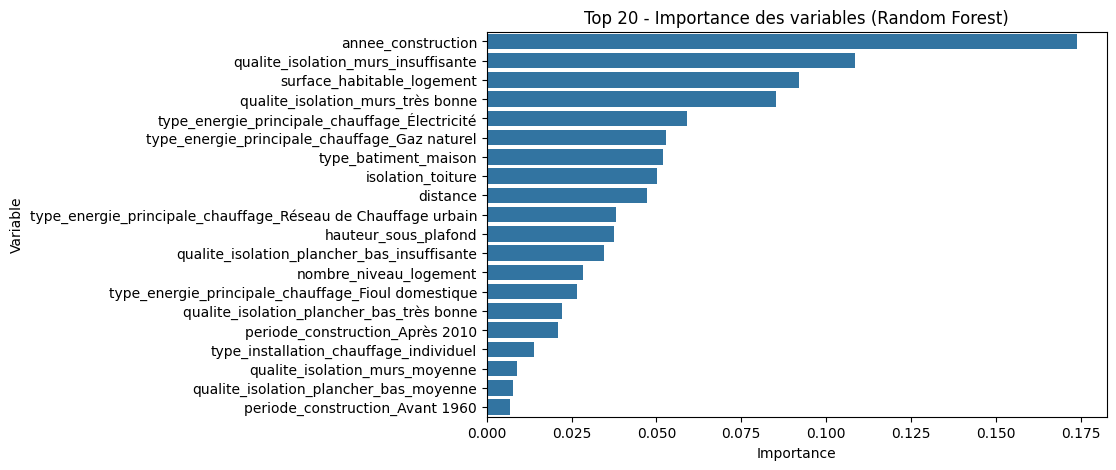

In [6]:
# Importance des features
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 20 - Importance des variables (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()


In [7]:
import joblib


# Sauvegarde du modèle dans un fichier .pkl
joblib.dump(rf_model, 'modele_dpe1e_300k.pkl', compress=3)

print("✅ Modèle sauvegardé dans 'modele_dpe_300k.pkl'")

✅ Modèle sauvegardé dans 'modele_dpe_300k.pkl'
